# Labelled science phrases: building the D2 candidate-phrase labels (demo)

This notebook demos **`data.py`**, the script that standardises the prepared datasets of the *emerging scientific concepts* study into the `exp_sel_data_out` schema (`{"input", "output", "metadata_*"}` rows grouped by dataset).

The artifact has seven datasets (D1 OpenAlex corpus, **D2 LLM-labelled candidate phrases**, D3 variant pairs, D4a/b human anchors, D5 phrase pool, D6 held-out works). This demo runs the builder for **D2 `llm_labelled_candidate_phrases`**, the semantic-grounding training/test set:

* candidate noun-phrase / acronym keys mined from OpenAlex abstracts (spaCy + Schwartz-Hearst);
* each key labelled `CONCEPT / NOT_CONCEPT / TOO_GENERIC / VARIANT_OF` by two LLMs (**A** = gemini-2.5-flash-lite, **B** = gpt-4.1-nano), with a **claude-haiku-4.5 adjudicator** on A/B disagreements and on a 200-item "silver gold" set;
* `d2_labels()` merges those labels into one final label: adjudicator > A/B consensus > `UNRESOLVED`. It then assigns the fold (train/test by variant cluster, or `pool_screen`) and adds the stratum and quality metadata.

**Demo data:** `mini_demo_data.json` holds a curated **100-key subset** of the four raw inputs `d2_labels()` reads (`labelling/items.json`, `labels_AB.json`, `labels_adj.json`, `split.json`). It covers the train, test and pool-screen folds, adjudicated and consensus items, acronyms and non-novel supplements. The full artifact has 4,599 keys.

> Labels are LLM-adjudicated **silver** labels; no human has checked them (`metadata_human_checked = False`).

## Setup
Install dependencies. `loguru` is the only package the script needs that Colab lacks. The core scientific packages are installed at Colab's versions only when running outside Colab.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, sklearn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

Imports: this is the original import block of `data.py`. The original also imported `schwartz_hearst` (from `scripts/textnorm.py`) and `read_corpus_works` (from `scripts/rawio.py`). Those are used only by the D1/D4b builders, which this demo leaves out, so those two imports are commented out. The file log sink is also dropped, because `Path(__file__)` does not exist in a notebook. `pandas`, `matplotlib` and `sklearn` are added for the results cell.

In [2]:
from __future__ import annotations

import argparse
import ast
import json
import sys
from pathlib import Path

from loguru import logger

ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
# sys.path.insert(0, str(ROOT / "scripts"))
# from textnorm import schwartz_hearst  # noqa: E402   (only used by D4b)
# from rawio import read_corpus_works  # noqa: E402    (only used by D1)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# (ROOT / "logs").mkdir(exist_ok=True)
# logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")

LAB = ROOT / "labelling"
TD = ROOT / "temp" / "datasets"

# additional imports for the notebook's results section
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import cohen_kappa_score

## Load the demo data
Load the data from GitHub, falling back to the local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-1/dataset-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("items:", len(data["items"]), "| A labels:", len(data["labels_AB"]["A"]), "| B labels:", len(data["labels_AB"]["B"]),
      "| adjudicated:", len(data["labels_adj"]["labels"]), "| silver_gold_200 in subset:", len(data["labels_adj"]["silver_gold_200"]))

Curated 100-key subset of the D2 (llm_labelled_candidate_phrases) raw inputs read by data.py:d2_labels(): labelling/items.json, labels_AB.json, labels_adj.json, split.json
items: 100 | A labels: 100 | B labels: 99 | adjudicated: 36 | silver_gold_200 in subset: 21


## Config
`MAX_KEYS` limits how many candidate keys (in sorted order) `d2_labels()` processes. The whole demo subset is 100 keys and runs in well under a second. The original run processes **all 4,599 keys** of `labelling/items.json` (`MAX_KEYS = None`). `SHOW_N` sets how many rows the results table prints.

In [5]:
MAX_KEYS = 100   # original: None (all 4,599 keys in the full labelling/items.json)
SHOW_N = 15      # rows shown in the results table

## Shared helpers (verbatim from `data.py`)
* `jl` streams a JSONL file (used by the other dataset builders).
* `key_quality` flags known extraction defects: keys that start with punctuation or a non-Latin script, and publisher boilerplate such as "© … Elsevier". The flags go into the metadata. The keys themselves are not dropped, so outputs stay reproducible.
* `s` makes sure `input`/`output` are strings, JSON-encoding them if needed.

In [6]:
def jl(p: Path):
    with p.open() as f:
        for line in f:
            if line.strip():
                yield json.loads(line)


KEY_OK = __import__("re").compile(r"^[a-z0-9α-ω]")
BOILER = ("©", "wiley periodical", "all rights reserved", "elsevier")


def key_quality(k: str) -> str:
    """Known extraction defect flag (documented in README): keys that start with punctuation/symbols,
    non-Latin script or publisher boilerplate. The normaliser is left unchanged so outputs stay reproducible."""
    if any(b in k for b in BOILER):
        return "boilerplate"
    if not KEY_OK.match(k):
        return "malformed_leading_char"
    return "ok"


def s(x) -> str:
    return x if isinstance(x, str) else json.dumps(x, ensure_ascii=False)

## D2 builder: `band` + `d2_labels`
The core of the demo. For each candidate key:
1. **Format labels**: `fmt()` turns `VARIANT_OF` into `VARIANT_OF:<canonical key>` when the model named the canonical form.
2. **Resolve the final label**: the adjudicator's label wins if there is one; otherwise use the A/B consensus; otherwise `UNRESOLVED`.
3. **Assign the fold**: pool-screen items (track `P`) go to `pool_screen`. Labelled items take the train/test split by *variant cluster*, so no surface form leaks between splits. Unresolved test items are excluded as `test_unresolved_excluded`.
4. **Build the stratum**: occurrence band × surface form type (1/2/3+ tokens or acronym) × macro domain.

The only changes from the original are the four input lines, which now read from the loaded `data` instead of `labelling/*.json`, and the `[:MAX_KEYS]` slice.

In [7]:
def band(n: int) -> str:
    return "3-5" if n <= 5 else "6-20" if n <= 20 else "21-100" if n <= 100 else ">100"


def d2_labels() -> list[dict]:
    items = data["items"]          # original: json.loads((LAB / "items.json").read_text())
    AB = data["labels_AB"]         # original: json.loads((LAB / "labels_AB.json").read_text())
    ADJ = data["labels_adj"]       # original: json.loads((LAB / "labels_adj.json").read_text())
    sp = data["split"]             # original: json.loads((LAB / "split.json").read_text())
    silver = set(ADJ["silver_gold_200"])
    adj = ADJ["labels"]
    out = []
    for k in sorted(items)[:MAX_KEYS]:
        it = items[k]
        a, b, j = AB["A"].get(k, {}), AB["B"].get(k, {}), adj.get(k, {})

        def fmt(r: dict) -> str | None:
            if not r.get("label"):
                return None
            return f"VARIANT_OF:{r['variant_of']}" if r["label"] == "VARIANT_OF" and r.get("variant_of") else r["label"]

        la, lb, lj = fmt(a), fmt(b), fmt(j)
        if lj:
            final, basis = lj, "adjudicator"
        elif la and la == lb:
            final, basis = la, "A/B consensus"
        else:
            final, basis = "UNRESOLVED", "A/B disagree, not adjudicated" if la and lb else "missing label"
        if it["track"] == "P":
            fold = "pool_screen"
        else:
            fold = sp["split"][k]
            if fold == "test" and final == "UNRESOLVED":
                fold = "test_unresolved_excluded"
        st = it["stats"]
        form = "acronym" if st["is_acronym_long_form"] else ("1tok" if st["n_tokens"] == 1 else "2tok" if st["n_tokens"] == 2 else "3+tok")
        inp = {"key": k, "surface_forms": it["surface_forms"],
               "acronym_short_forms": it.get("acronym_short_forms", []),
               "snippets": it["snippets"], "n_sample_occ": st["n_occ"],
               "first_sample_year": st["first_main_year"], "n_fields": st["n_fields"]}
        out.append({
            "input": s(inp), "output": final, "metadata_fold": fold,
            "metadata_track": {"L": "L_novel", "L_nonnovel": "L_nonnovel_supplement", "P": "P_pool_screen"}[it["track"]],
            "metadata_label_basis": basis, "metadata_silver_gold_200": k in silver,
            "metadata_label_A": la, "metadata_label_B": lb, "metadata_label_adj": lj,
            "metadata_rationale_A": a.get("rationale"), "metadata_rationale_B": b.get("rationale"),
            "metadata_rationale_adj": j.get("rationale"),
            "metadata_confidence_A": a.get("confidence"), "metadata_confidence_B": b.get("confidence"),
            "metadata_confidence_adj": j.get("confidence"),
            "metadata_model_A": a.get("model"), "metadata_model_B": b.get("model"), "metadata_model_adj": j.get("model"),
            "metadata_label_date": a.get("date") or b.get("date"),
            "metadata_batch_cost_usd_A": a.get("batch_cost"), "metadata_batch_cost_usd_B": b.get("batch_cost"),
            "metadata_variant_cluster": sp["cluster"].get(k),
            "metadata_stratum": f"{band(st['n_occ']) if st['n_occ'] >= 3 else str(st['n_occ'])}|{form}|{st['macro_domain']}",
            "metadata_macro_domain": st["macro_domain"], "metadata_cvalue": st["cvalue"],
            "metadata_in_prescreen_or_pre2005": st["in_pre"], "metadata_audit_arm": bool(it.get("audit_arm", False)),
            "metadata_key_quality": key_quality(k),
            "metadata_human_checked": False,
        })
    return out

## Schema check (verbatim `check_rows`)
Every row must have string `input`/`output`, and every other field must start with `metadata_`. This is the `exp_sel_data_out` contract.

In [8]:
def check_rows(name: str, rows: list[dict]) -> None:
    bad = 0
    for r in rows:
        if not isinstance(r.get("input"), str) or not isinstance(r.get("output"), str):
            bad += 1
        for k in r:
            if k not in ("input", "output") and not k.startswith("metadata_"):
                raise ValueError(f"{name}: illegal field {k}")
    if bad:
        raise ValueError(f"{name}: {bad} rows with non-string input/output")

## Run the builder (the `main()` loop, D2 only)
`main()` iterates over `SELECTED` (the seven dataset builders), checks each dataset's rows and wraps them into `{"metadata", "datasets": [...]}`. Here it runs only D2 and keeps the result in memory instead of writing `full_data_out.json`.

In [9]:
groups = []
for name, fn in [("llm_labelled_candidate_phrases", d2_labels)]:
    rows = fn()
    check_rows(name, rows)
    logger.info(f"{name}: {len(rows)} examples")
    groups.append({"dataset": name, "examples": rows})
meta = {
    "artifact": "gen_plan_dataset_4_idx4: labelled concept phrases and survivorship-free phrase pool",
    "created": "2026-09-28",
    "label_status": "D2/D3 LLM labels are LLM-adjudicated SILVER labels; no human has checked them (human_checked=false).",
}
out_obj = {"metadata": meta, "datasets": groups}
print(json.dumps(groups[0]["examples"][0], ensure_ascii=False, indent=1)[:2500])

12:13:39|INFO   |llm_labelled_candidate_phrases: 100 examples


{
 "input": "{\"key\": \"adequate bone volume\", \"surface_forms\": [\"adequate bone volume\"], \"acronym_short_forms\": [], \"snippets\": [{\"work_id\": \"W2005364965\", \"year\": 2005, \"text\": \"These include adequate bone volume, proper soft tissue thickness as well as esthetic appearing restorations.\"}, {\"work_id\": \"W2058698023\", \"year\": 2005, \"text\": \"Insufficient alveolar contours may require bone grafting procedures to restore an adequate bone volume before implant placement.\"}, {\"work_id\": \"W2052665696\", \"year\": 2008, \"text\": \"The reconstruction of atrophies with adequate bone volume and density has become a viable treatment option with high predictability and success rates.\"}], \"n_sample_occ\": 3, \"first_sample_year\": 2005, \"n_fields\": 1}",
 "output": "CONCEPT",
 "metadata_fold": "test",
 "metadata_track": "L_novel",
 "metadata_label_basis": "A/B consensus",
 "metadata_silver_gold_200": false,
 "metadata_label_A": "CONCEPT",
 "metadata_label_B": "CO

## Results
A table of the standardised rows, then three views of label quality:
* the final label distribution per fold;
* the A (gemini) vs B (gpt-4.1-nano) confusion matrix with Cohen's κ. On the full data κ ≈ 0.26: **B over-labels `CONCEPT`**, which is why disagreements go to the adjudicator;
* how final labels were resolved (`metadata_label_basis`).

                        key      output metadata_fold          metadata_label_basis metadata_label_A metadata_label_B metadata_label_adj                metadata_stratum metadata_key_quality
       adequate bone volume     CONCEPT          test                 A/B consensus          CONCEPT          CONCEPT               None                3-5|3+tok|health                   ok
 agar well diffusion method     CONCEPT          test                 A/B consensus          CONCEPT          CONCEPT               None                 6-20|3+tok|life                   ok
               alpha fe 2 o     CONCEPT         train                 A/B consensus          CONCEPT          CONCEPT               None              3-5|3+tok|physical                   ok
                  analyst ®  UNRESOLVED   pool_screen A/B disagree, not adjudicated      NOT_CONCEPT          CONCEPT               None                 1|2tok|physical                   ok
     and commitment therapy     CONCEPT          t

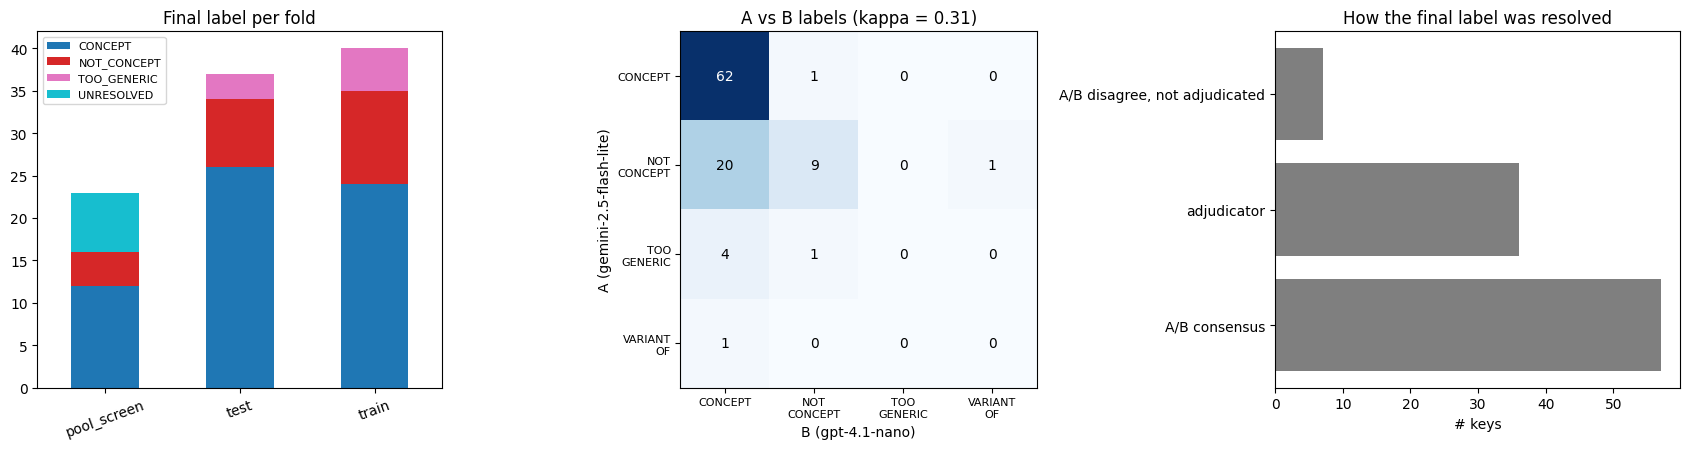

In [10]:
df = pd.DataFrame(groups[0]["examples"])
df["key"] = df["input"].map(lambda x: json.loads(x)["key"])
pd.set_option("display.width", 200, "display.max_colwidth", 40)
print(df[["key", "output", "metadata_fold", "metadata_label_basis", "metadata_label_A", "metadata_label_B",
          "metadata_label_adj", "metadata_stratum", "metadata_key_quality"]].head(SHOW_N).to_string(index=False))

print("\nFinal label x fold:")
print(pd.crosstab(df["output"], df["metadata_fold"], margins=True).to_string())
print("\nLabel basis:", dict(Counter(df["metadata_label_basis"])))
print("Key quality flags:", dict(Counter(df["metadata_key_quality"])))

# A vs B agreement (base label, VARIANT_OF:<x> collapsed to VARIANT_OF)
base = lambda v: v.split(":")[0] if isinstance(v, str) else v
both = df.dropna(subset=["metadata_label_A", "metadata_label_B"])
la, lb = both["metadata_label_A"].map(base), both["metadata_label_B"].map(base)
LABELS = ["CONCEPT", "NOT_CONCEPT", "TOO_GENERIC", "VARIANT_OF"]
kappa = cohen_kappa_score(la, lb, labels=LABELS) if len(both) > 1 else float("nan")
print(f"\nA-B raw agreement: {(la == lb).mean():.3f}  | Cohen's kappa (4-class): {kappa:.3f}  (n={len(both)})")
adj_rows = df[df["metadata_label_adj"].notna()]
if len(adj_rows):
    print(f"A agrees with adjudicator on {(adj_rows['metadata_label_A'].map(base) == adj_rows['metadata_label_adj'].map(base)).mean():.3f}, "
          f"B on {(adj_rows['metadata_label_B'].map(base) == adj_rows['metadata_label_adj'].map(base)).mean():.3f} of {len(adj_rows)} adjudicated keys")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
ct = pd.crosstab(df["metadata_fold"], df["output"].map(base))
ct.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab10")
axes[0].set_title("Final label per fold"); axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=8)

cm = pd.crosstab(la, lb).reindex(index=LABELS, columns=LABELS, fill_value=0)
axes[1].imshow(cm.values, cmap="Blues")
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        axes[1].text(j, i, cm.values[i, j], ha="center", va="center", color="white" if cm.values[i, j] > cm.values.max() / 2 else "black")
axes[1].set_xticks(range(len(LABELS)), [l.replace("_", "\n") for l in LABELS], fontsize=8)
axes[1].set_yticks(range(len(LABELS)), [l.replace("_", "\n") for l in LABELS], fontsize=8)
axes[1].set_xlabel("B (gpt-4.1-nano)"); axes[1].set_ylabel("A (gemini-2.5-flash-lite)")
axes[1].set_title(f"A vs B labels (kappa = {kappa:.2f})")

basis = df["metadata_label_basis"].value_counts()
axes[2].barh(basis.index, basis.values, color="tab:gray")
axes[2].set_title("How the final label was resolved"); axes[2].set_xlabel("# keys")
plt.tight_layout(); plt.show()